# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
* **Linear models only capture straight-line relationships and are best for ouputs that are continuous values. General linear models extend this by handling binary, count, or categorical responses through link functions. Activation functions and latent variable ideas also allow more complex and realistic patterns than a basic linear regression.**

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
* **Binary and categorical cross entropy are effective loss funcitons because they compare predicted probabilities to the true class labels. It heavily penalizes predictions that are confidently wrong and rewards assigning high probability to the correct class.**

3. True or false, and explain: Logistic regression is a linear model.
* **True. Logistic regression is linear in the sense that it models the log-odds as a linear combination of the predictors. The final predicted probability is nonlinear because the logistic function is applied afterward.**

4. True or false, and explain: Logistic regression cannot be used for classification.
* **False. Logistic regression is commonly used for classification problems. It can predict class probabilities, which can then be converted into labels using a cutoff like at 0.5.**

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

Not exactly. A coefficient in a logistic regression represents the change in the log-odds of the output for a 1 unit increase in the feature.Its effect on predicted probability depends on the current probability level.


6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

* **False. Logistic regression uses a nonlinear output function, but it is still linear in the predictors. Feature engineering such as interaction terms or transformations can improve performance when relationships are more complex.**


7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

* **False. Logistic regression is better for binary or categorical outcomes because it predicts probabilities between 0 and 1. Ordinary least squares is still more appropriate for continuous response variables.**

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

In [141]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

data = pd.read_csv("data/data.csv", delimiter=";")

cols = [
    "Debtor", "Tuition fees up to date", "Scholarship holder",
    "Age at enrollment", "Curricular units 1st sem (approved)", "Target"
]

data = data[cols].copy()

data = data.dropna()

data["dropout"] = data["Target"].map({"Graduate": 0, "Enrolled": 0, "Dropout": 1})

data.head()


,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,dropout
0,0,1,0,20,0,Dropout,1
1,0,0,0,19,6,Graduate,0
2,0,0,0,19,0,Dropout,1
3,0,1,0,20,6,Graduate,0
4,0,1,0,45,5,Graduate,0


In [142]:
data.shape

(4424, 7)


2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?


In [143]:
X = data[["Debtor", "Tuition fees up to date", "Scholarship holder", "Age at enrollment"]]
y = data["dropout"]

log_reg = LogisticRegression()
log_reg.fit(X, y)

coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_reg.coef_[0]
})
print(coef)

                   Feature  Coefficient
0                   Debtor     0.530625
1  Tuition fees up to date    -2.556542
2       Scholarship holder    -1.227442
3        Age at enrollment     0.049925


**Debtor predicts the highest dropout probability. Tuition fees up to date and Scholarship holder predict a lower dropout probability, with the former predicting the lowest. Yes, being up to date on tuition seems to suggest a reduction in dropout risk.**


3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?


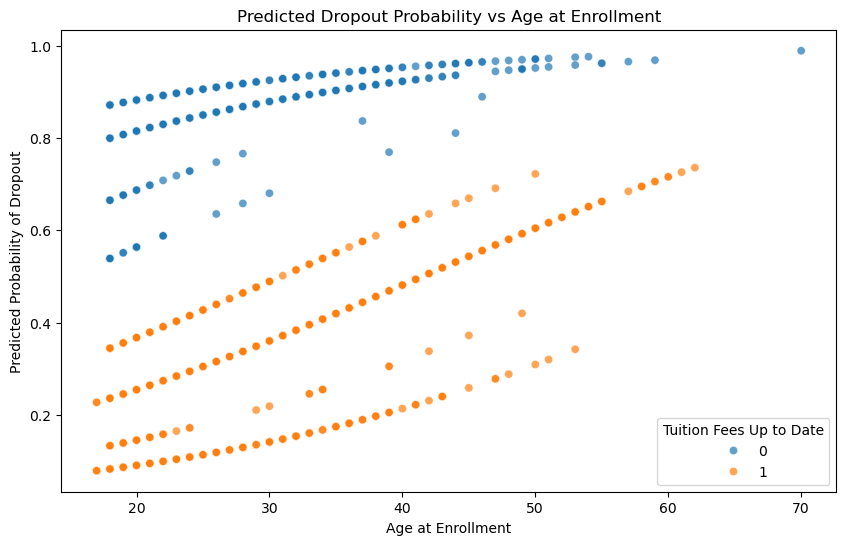

Average predicted dropout probability (up to date): 0.24808971151173678
Average predicted dropout probability (not up to date): 0.860674645474941
Average reduction in predicted dropout probability: 0.6125849339632042


In [144]:
import matplotlib.pyplot as plt
import seaborn as sns

data["pred_dropout_prob_logreg"] = log_reg.predict_proba(X)[:, 1]

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=data,
    x="Age at enrollment",
    y="pred_dropout_prob_logreg",
    hue="Tuition fees up to date",
    alpha=0.7
)

plt.title("Predicted Dropout Probability vs Age at Enrollment")
plt.xlabel("Age at Enrollment")
plt.ylabel("Predicted Probability of Dropout")
plt.legend(title="Tuition Fees Up to Date")
plt.show()

avg_prob_up_to_date = data[data["Tuition fees up to date"] == 1]["pred_dropout_prob_logreg"].mean()
avg_prob_not_up_to_date = data[data["Tuition fees up to date"] == 0]["pred_dropout_prob_logreg"].mean()

diff = avg_prob_not_up_to_date - avg_prob_up_to_date

print("Average predicted dropout probability (up to date):", avg_prob_up_to_date)
print("Average predicted dropout probability (not up to date):", avg_prob_not_up_to_date)
print("Average reduction in predicted dropout probability:", diff)

**By the looks of it, it seems that the two groups have the largest difference at younger ages. Because of this, I would say that at around age 20, being up to date on tuition seems to reduce dropout probability the most. On average, being up to date on tuition decreases the predicted probability of a dropout by 0.613.**


4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?


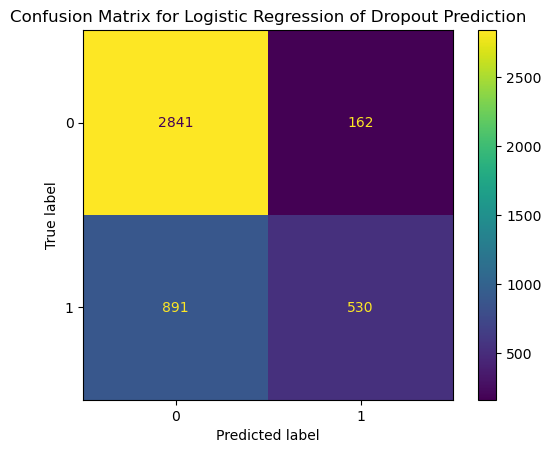

Accuracy: 0.7619801084990958


In [145]:
pred = log_reg.predict(X)
cm = confusion_matrix(y, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg.classes_)
disp.plot()
plt.title("Confusion Matrix for Logistic Regression of Dropout Prediction")
plt.show()

accuracy = (cm[0, 0] + cm[1, 1]) / cm.sum()
print("Accuracy:", accuracy)


5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.


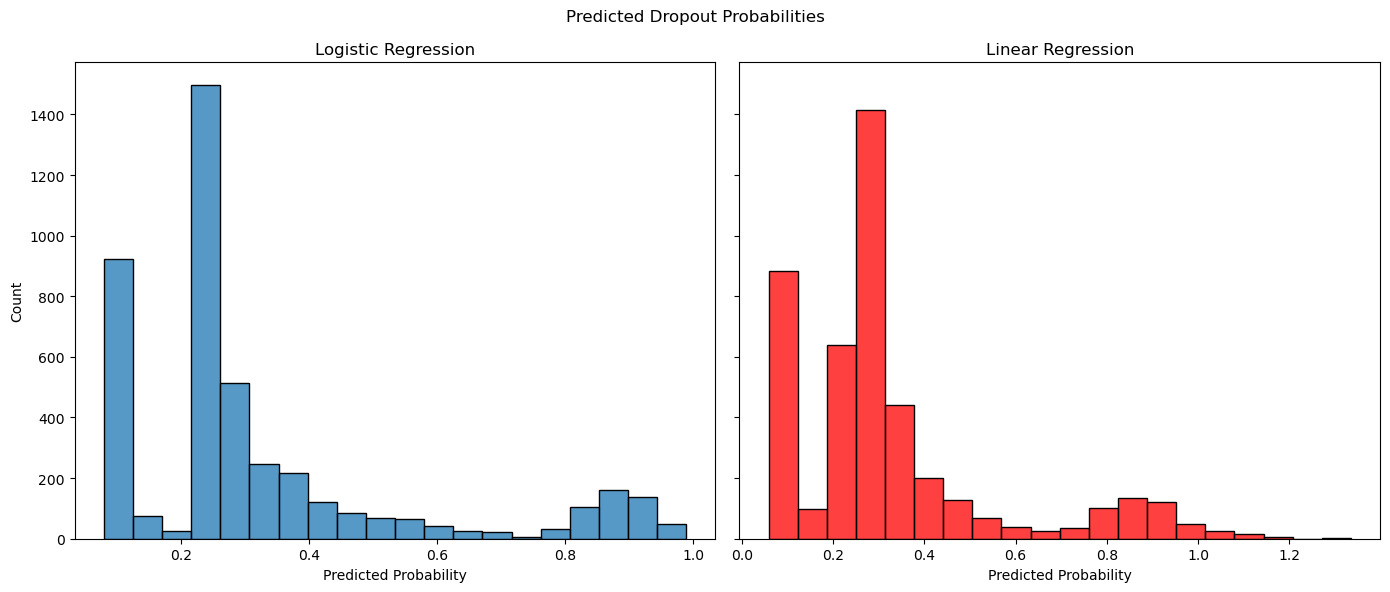

Logistic Regression Accuracy: 0.7619801084990958
Linear Regression Accuracy: 0.7633363471971067
Linear Regression Min Prediction: 0.05832035022574156
Linear Regression Max Prediction: 1.334953570675864


In [146]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)
data["pred_dropout_prob_linreg"] = lin_reg.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

sns.histplot(
    data["pred_dropout_prob_logreg"],
    bins=20,
    ax=axes[0]
)
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted Probability")
axes[0].set_ylabel("Count")

sns.histplot(
    data["pred_dropout_prob_linreg"],
    bins=20,
    ax=axes[1], 
    color="red"
)
axes[1].set_title("Linear Regression")
axes[1].set_xlabel("Predicted Probability")
axes[1].set_ylabel("Count")

plt.suptitle("Predicted Dropout Probabilities")
plt.tight_layout()
plt.show()

log_preds = (data["pred_dropout_prob_logreg"] >= 0.5).astype(int)
lin_preds = (data["pred_dropout_prob_linreg"] >= 0.5).astype(int)

log_acc = accuracy_score(y, log_preds)
lin_acc = accuracy_score(y, lin_preds)

print("Logistic Regression Accuracy:", log_acc)
print("Linear Regression Accuracy:", lin_acc)
print("Linear Regression Min Prediction:", data["pred_dropout_prob_linreg"].min())
print("Linear Regression Max Prediction:", data["pred_dropout_prob_linreg"].max())


**Both models may have similar classification accuracy at a 0.5 threshold, but logistic regression performs better because it produces valid probabilities constrained between 0 and 1. The linear model gives unrealistic predictions above 1, showing it is less appropriate and less reliable for the binary dropout outcome.**


6. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?
* **The students that are the most at-risk of dropping out are those who are in debt, older at enrollment, have unpaid tuition fees, and are not on scholarship. It seems that financial factors have the greatest impact, so I think measures such as financial aid, or at the least asssistance on how to finance their education would help at-risk students stay enrolled.**


7. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


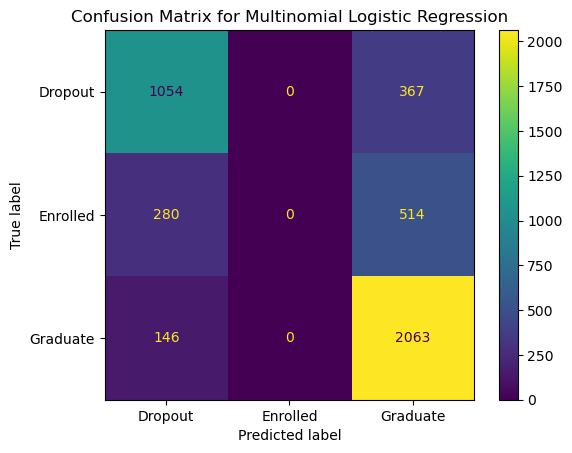

Multinomial Logistic Regression Accuracy: 0.7045660036166366
    Dropout  Enrolled  Graduate
0  0.680547  0.210464  0.108989
1  0.695414  0.146043  0.158543
2  0.952988  0.041199  0.005813
3  0.117808  0.176983  0.705209
4  0.184227  0.212669  0.603104
Classes predicted: ['Dropout' 'Graduate']


In [147]:
x = data[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']]
y = data['Target']

multi_log_reg = LogisticRegression(multi_class='multinomial')
multi_log_reg.fit(x, y)

y_pred = multi_log_reg.predict(x)
y_prob = multi_log_reg.predict_proba(x)

accuracy_multi = accuracy_score(y, y_pred)

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=multi_log_reg.classes_)
disp.plot()
plt.title("Confusion Matrix for Multinomial Logistic Regression")
plt.show()
print("Multinomial Logistic Regression Accuracy:", accuracy_multi)

proba = pd.DataFrame(y_prob, columns=multi_log_reg.classes_)
print(proba.head())
print("Classes predicted:", np.unique(y_pred))

* **The multinomial logistic regression performed with 70% accuracy. The classification only preditcts 'Dropout' and 'Graduatae'. For the predicted probabilities, the model has non-zero probabilities for all classes including 'Enrolled'.**

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.


In [148]:
cirr = pd.read_csv("data/cirrhosis.csv")
cols = ["Bilirubin", "Edema", "Drug", "Stage", "Status"]

cirr = cirr[cols].copy()
print(cirr.shape)
cirr.head()

(418, 5)


,Bilirubin,Edema,Drug,Stage,Status
0,14.5,Y,D-penicillamine,4.0,D
1,1.1,N,D-penicillamine,3.0,C
2,1.4,S,D-penicillamine,4.0,D
3,1.8,S,D-penicillamine,4.0,D
4,3.4,N,Placebo,3.0,CL


In [149]:
print(cirr.isnull().sum())
cirr = cirr.dropna()

Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64


In [150]:
cirr.shape

(312, 5)

In [151]:
cirr["alive"] = (cirr["Status"] != "D").astype(int)
cirr.head()

,Bilirubin,Edema,Drug,Stage,Status,alive
0,14.5,Y,D-penicillamine,4.0,D,0
1,1.1,N,D-penicillamine,3.0,C,1
2,1.4,S,D-penicillamine,4.0,D,0
3,1.8,S,D-penicillamine,4.0,D,0
4,3.4,N,Placebo,3.0,CL,1


* **There were 106 and 6 missing values in the Drug and Stage columns respectively. So I dropped observations that were missing either.**


2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?


In [152]:
encodings = pd.get_dummies(cirr[["Edema", "Drug"]], drop_first=True)
X = pd.concat([cirr[["Bilirubin"]], encodings], axis=1)
y = cirr["alive"]

model = LogisticRegression()
model.fit(X, y)

coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})
print(coef)

        Feature  Coefficient
0     Bilirubin    -0.351424
1       Edema_S    -0.450677
2       Edema_Y    -1.611049
3  Drug_Placebo     0.231225


* **No, from the model and data, it does not appear that the drug improves surivial probability. High bilirubin predicts a lower survival rate. Edema despite diuretics has a lower survival probability than edema that is resolvable with diuretics.**


3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?


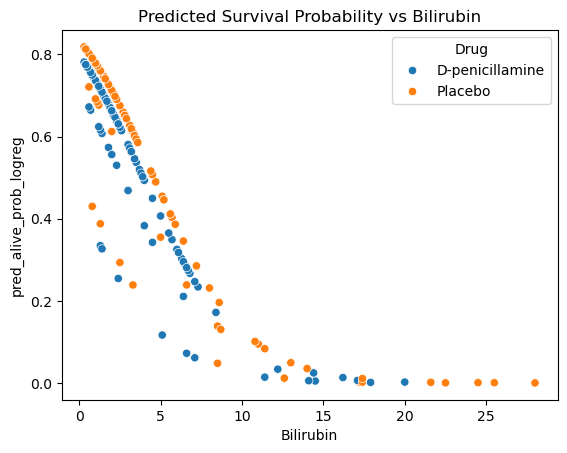

Average predicted survival probability (D-penicillamine): 0.590053809279959
Average predicted survival probability (Placebo): 0.6089023103184681
Difference in predicted survival probability: -0.018848501038509102


In [153]:
cirr["pred_alive_prob_logreg"] = model.predict_proba(X)[:, 1]

sns.scatterplot(data=cirr,
                x='Bilirubin',
                y='pred_alive_prob_logreg',
                hue='Drug')

plt.title("Predicted Survival Probability vs Bilirubin")
plt.show()

drug_mean    = cirr[cirr["Drug"] == "D-penicillamine"]["pred_alive_prob_logreg"].mean()
placebo_mean = cirr[cirr["Drug"] == "Placebo"]["pred_alive_prob_logreg"].mean()
diff = drug_mean - placebo_mean

print("Average predicted survival probability (D-penicillamine):", drug_mean)
print("Average predicted survival probability (Placebo):", placebo_mean)
print("Difference in predicted survival probability:", diff)


* **The scatter plot roughly shows that at varying Bilirubin levels, the placebo leads to higher surivival rate than the actual dryg. On average, patients who take the drug experience a decrease in probability of survival by 0.019.**


4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?


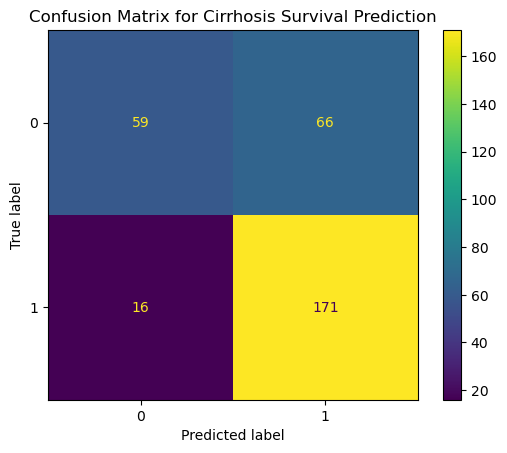

Accuracy: 0.7371794871794872


In [154]:
y_pred = model.predict(X)
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.title("Confusion Matrix for Cirrhosis Survival Prediction")
plt.show()

accuracy = accuracy_score(y, y_pred)
print("Accuracy:", accuracy)


5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.


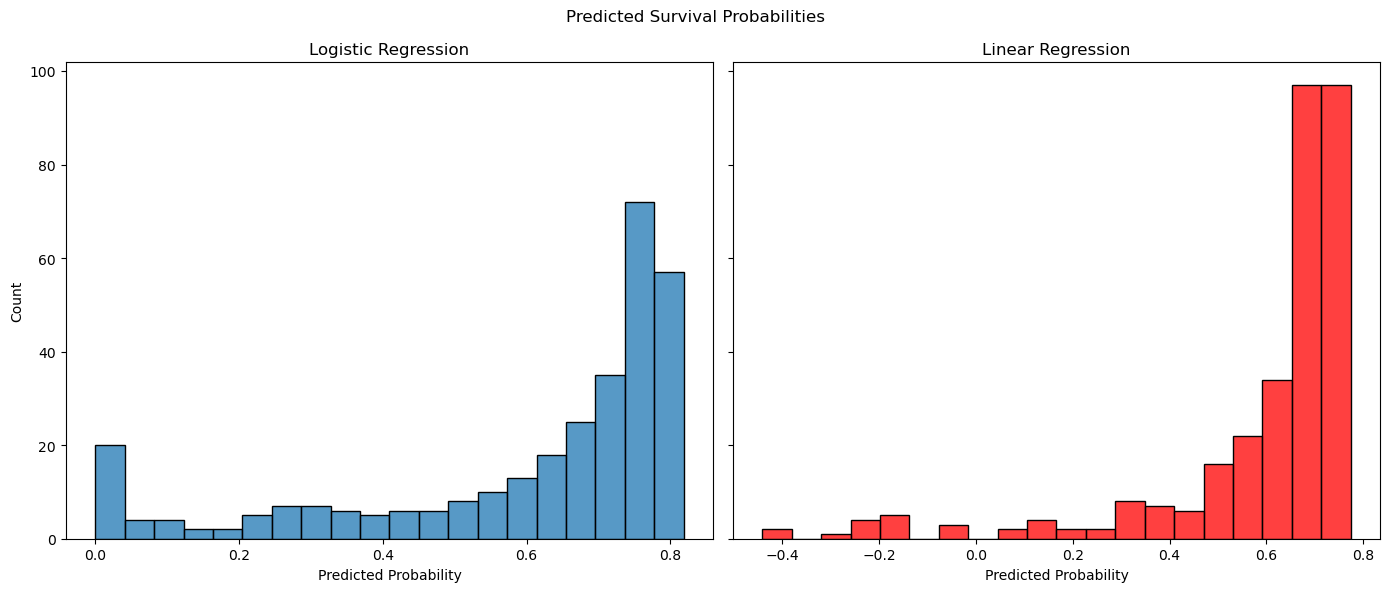

Logistic Regression Accuracy: 0.7371794871794872
Linear Regression Accuracy: 0.7211538461538461
Linear Regression Min Prediction: -0.4417396683935999
Linear Regression Max Prediction: 0.7738680250928712


In [155]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)
cirr["pred_alive_prob_linreg"] = lin_reg.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

sns.histplot(
    cirr["pred_alive_prob_logreg"],
    bins=20,
    ax=axes[0]
)
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted Probability")
axes[0].set_ylabel("Count")

sns.histplot(
    cirr["pred_alive_prob_linreg"],
    bins=20,
    ax=axes[1], 
    color="red"
)
axes[1].set_title("Linear Regression")
axes[1].set_xlabel("Predicted Probability")
axes[1].set_ylabel("Count")

plt.suptitle("Predicted Survival Probabilities")
plt.tight_layout()
plt.show()

log_preds = (cirr["pred_alive_prob_logreg"] >= 0.5).astype(int)
lin_preds = (cirr["pred_alive_prob_linreg"] >= 0.5).astype(int)

log_acc = accuracy_score(y, log_preds)
lin_acc = accuracy_score(y, lin_preds)

print("Logistic Regression Accuracy:", log_acc)
print("Linear Regression Accuracy:", lin_acc)
print("Linear Regression Min Prediction:", cirr["pred_alive_prob_linreg"].min())
print("Linear Regression Max Prediction:", cirr["pred_alive_prob_linreg"].max())

* **The logistic regression predicts probabilities between 0 and 1, while the linear regression outputs some probabilities that lie outside of 0 and 1 (the minimum prediction value is -0.44). For this reason, the logistic regression is more realistic for predicting survival probabilities.**


6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


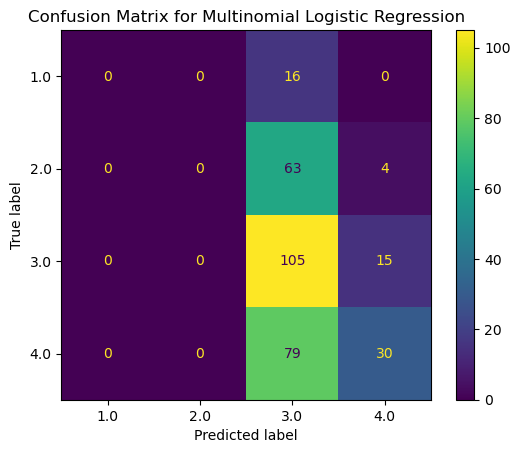

Classes predicted:  [3. 4.]
        1.0       2.0       3.0       4.0
0  0.000013  0.032535  0.143611  0.823841
1  0.072394  0.251555  0.397520  0.278531
2  0.029263  0.181531  0.395694  0.393512
3  0.023272  0.176777  0.397217  0.402734
4  0.020204  0.224965  0.423342  0.331488


In [156]:
encodings = pd.get_dummies(cirr[["Edema"]], drop_first=True)
X = pd.concat([cirr[["Bilirubin"]], encodings], axis=1)
y = cirr["Stage"]

multi_log_reg = LogisticRegression(multi_class='multinomial')
multi_log_reg.fit(X, y)

y_pred = multi_log_reg.predict(X)
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=multi_log_reg.classes_)
disp.plot()
plt.title("Confusion Matrix for Multinomial Logistic Regression")
plt.show()

print("Classes predicted: ", np.unique(y_pred))

proba = pd.DataFrame(multi_log_reg.predict_proba(X), columns=multi_log_reg.classes_)
print(proba.head())

* **The model shows a disproportionate predicting of stages. It seems that it only predicts stages 3 and 4. Predicting probabilities appears to perform better as every stage has a non-zero probability. This reveals that the model considers each of the four stages, but since stage 1 and stage 2 never have the highest probabilities, it doesn't classify it as either of them.**

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

https://github.com/nathan4luu/undergrad_ml_assignments/blob/main/hw5_q4.JPG